xyz2grd [WARNING]: (x_max-x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
xyz2grd [WARNING]: (y_max-y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
xyz2grd (gmtapi_init_grdheader): Please select compatible -R and -I values
xyz2grd [WARNING]: Encountered first invalid binary data record near/at line # 579439
xyz2grd [WARNING]: Likely causes:
xyz2grd [WARNING]: (1) Invalid x and/or y values, i.e. NaNs.


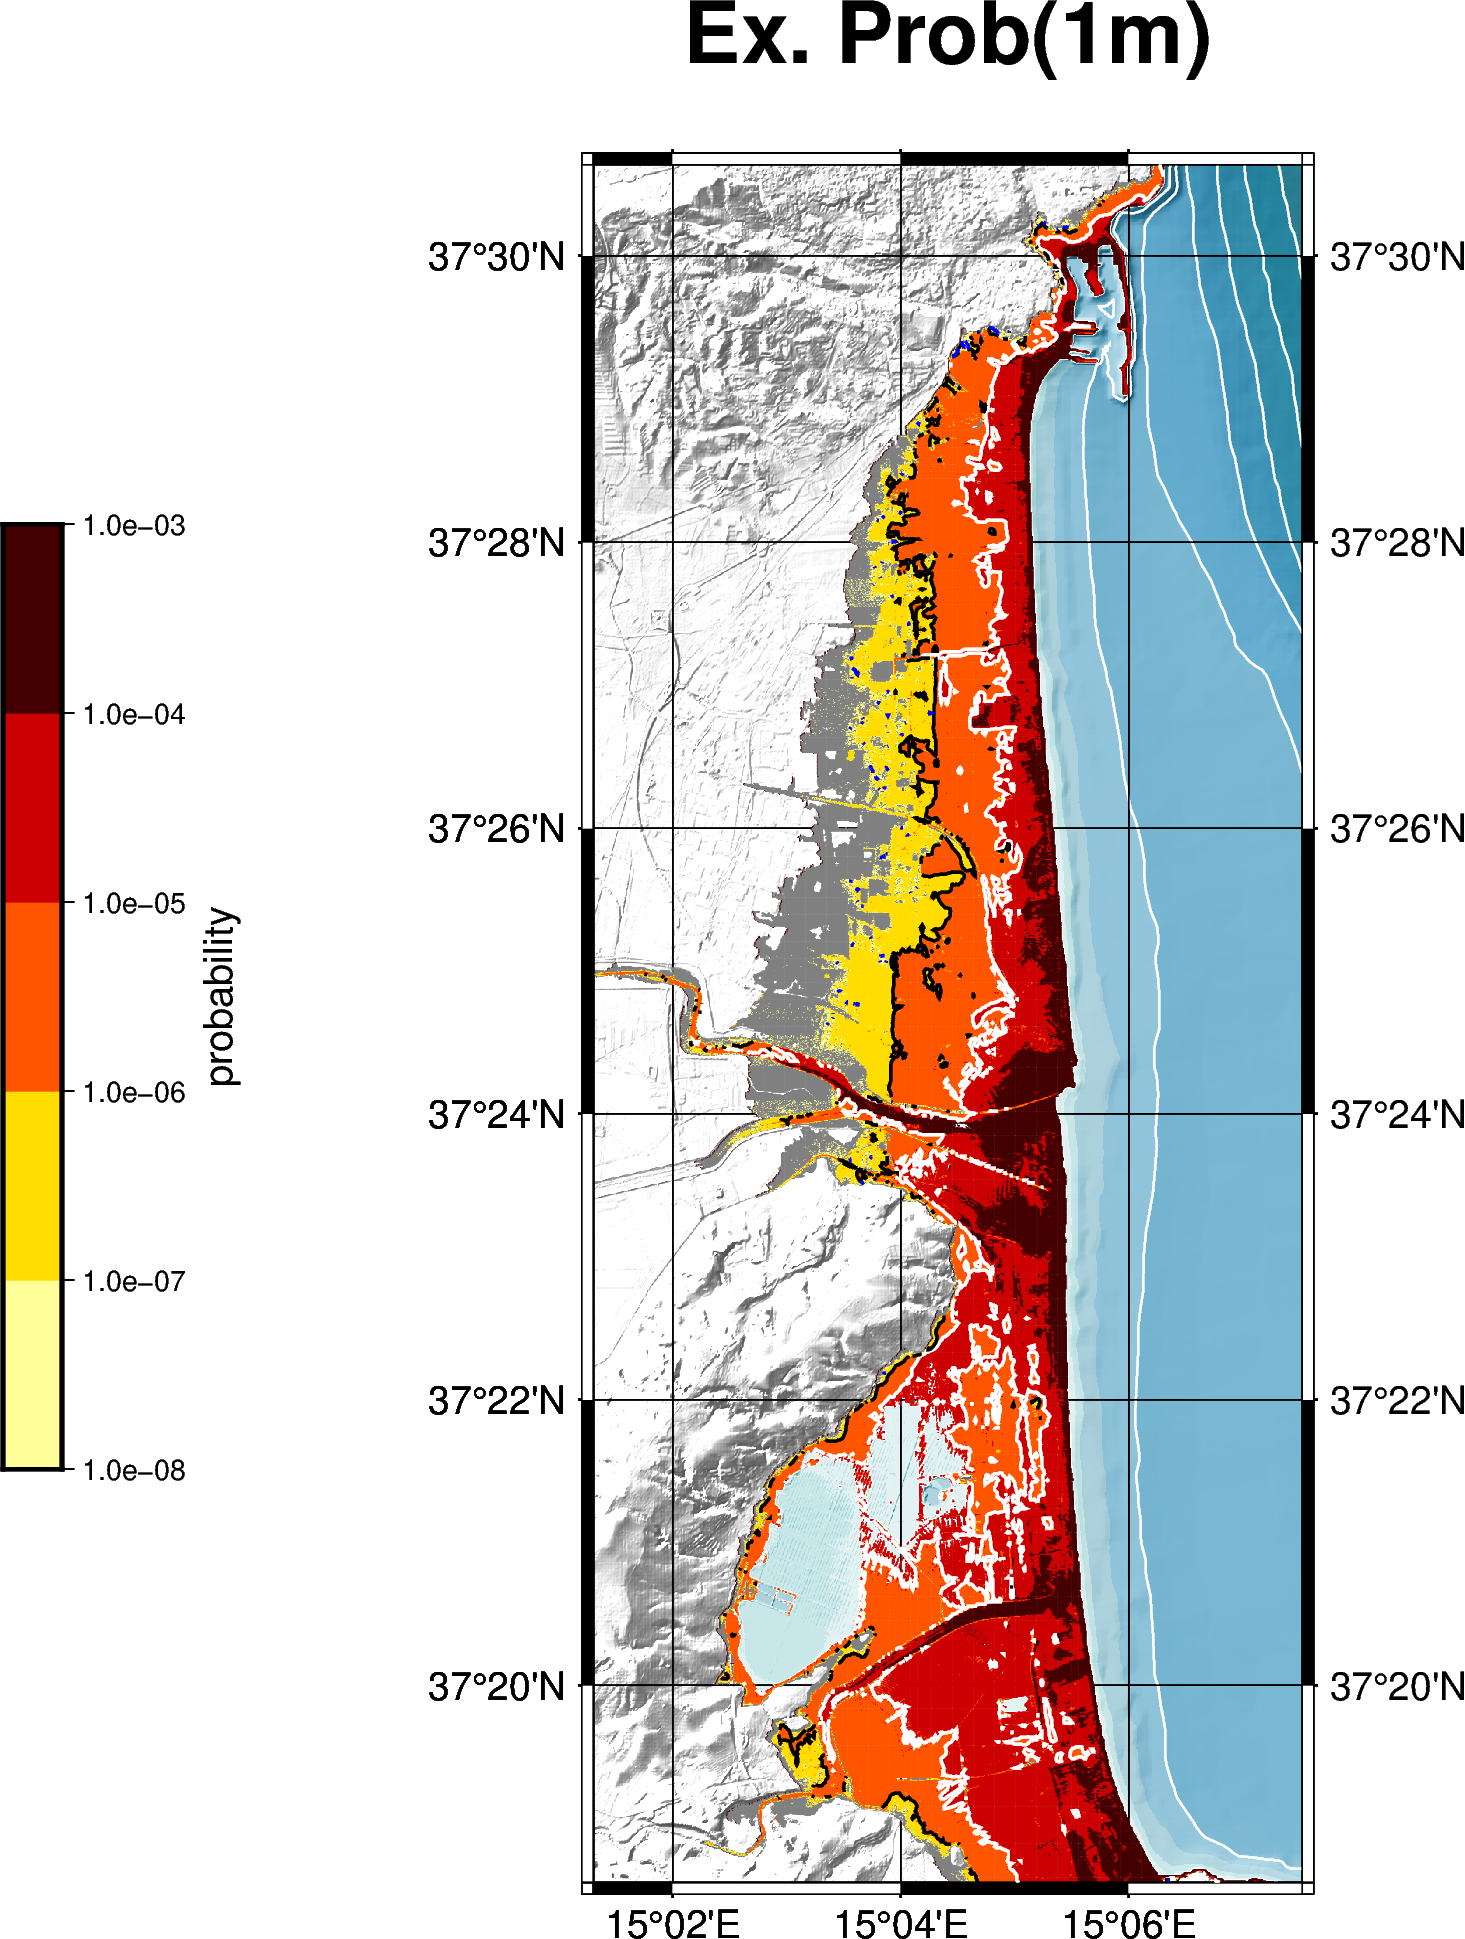

In [8]:
import pandas as pd
import numpy as np
import xarray as xr
import pygmt

pygmt.config(FORMAT_FLOAT_MAP="%1.1e")  
#select particular representative gauge
reg = 'CT'
list_size = ['529']   
columnname = str(38)
mask_size = '892'
train_size = list_size[0]

# Load the elevation from netcdf grid
grid_CT = xr.open_dataset('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/processed/CT_defbathy.nc',engine='netcdf4')
#get lat long limits from the grid
ymin = grid_CT['y'].min().values
ymax = grid_CT['y'].max().values
xmin = grid_CT['x'].min().values
xmax = grid_CT['x'].max().values

grid_CT_P1 = xr.open_dataset('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/r2_topo_test.nc',engine='netcdf4')
temp = grid_CT_P1['r2topo']
temp = temp.where(temp>0,0)
grid_CT_P1['r2topo'] = temp

# Plot grid
fig = pygmt.Figure()

with fig.subplot(
        nrows=1,
        ncols=1,
        subsize = ["8","20c"],
        sharey = True,
        frame = ["ag"],
        clearance  = "w4.5c",
        ):
    with fig.set_panel(0):
        cptfile = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/bathy.cpt'
        cmap = pygmt.makecpt(cmap=cptfile,continuous=False)
        fig.grdimage(grid_CT['z'], cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["+tEx. Prob(1m)"])
        fig.grdcontour(grid_CT['z'], levels=10, pen='0.5p,white', limit=[-100, 0],projection='M6c')
        cptfile = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/scripts/PaperIIPlots/PaperI/r2/r2only.cpt'
        cmap = pygmt.makecpt(cmap='hot',reverse=True, log=True, series = [-8,-3,1],background='white')
        idx_val = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/_Grid_scores_1658_PSHalf.txt', sep=",")
        ex_rate = np.load(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/{reg}/multifoldMC/PTHA/pred_PTHArate_{train_size}.npy')
        #replace 0 with nan
        ex_rate[ex_rate == 0] = np.nan
        fig.plot(x=idx_val['lon'], y=idx_val['lat'],fill=ex_rate[:,0],style='s0.0075c',cmap = True,projection='M6c',frame = ["ag"])
        grid_rate = pygmt.xyz2grd(x=idx_val['lon'], y=idx_val['lat'], z=ex_rate[:,0], spacing='1s', region=[xmin,xmax,ymin,ymax])
        # fig.grdimage(grid_rate, cmap=True, shading=True,region=[xmin,xmax,ymin,ymax],projection='M6c',frame = ["ag"])
        fig.grdcontour(grid_rate, levels=[1e-5], pen='0.75p,white', limit=[1e-8,1e-3],projection='M6c')
        fig.grdcontour(grid_rate, levels=[1e-6], pen='0.75p,black', limit=[1e-8,1e-3],projection='M6c')
        fig.grdcontour(grid_rate, levels=[1e-7], pen='0.75p,blue', limit=[1e-8,1e-3],projection='M6c')
        fig.colorbar(frame=["x+lprobability"], position="JML+o4.5c/-2.5c+w8c/0.5c+m", log = True)  
fig.show()

#save as csv 
table = pd.DataFrame({'lon': idx_val['lon'], 'lat': idx_val['lat'], 'ex_rate': ex_rate[:,0]})
table.to_csv(f'//mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/model/CT/multifoldMC/PTHA/ex_rate_{train_size}.csv', index=False)